## Exporting the dim.reductions from individual Seurat objects

- last updated: 11/7/2024

### Goals:
- export the dimensionality reduction from the individual objects
- NOTE that the objects still has "low_quality" cells from Merlin's annotation, which needs to be filtered later.


In [1]:
suppressMessages(library(Signac))
suppressMessages(library(Seurat))
suppressMessages(library(GenomeInfoDb))

library(ggplot2)
library(dplyr)
library(RColorBrewer)
library(patchwork)
library(stringr)
library(VennDiagram)
library(GenomicRanges)
library(Matrix)

# zebrafish genome
library(BSgenome.Drerio.UCSC.danRer11)


Attaching package: ‘dplyr’


The following object is masked from ‘package:GenomeInfoDb’:

    intersect


The following objects are masked from ‘package:IRanges’:

    collapse, desc, intersect, setdiff, slice, union


The following objects are masked from ‘package:S4Vectors’:

    first, intersect, rename, setdiff, setequal, union


The following objects are masked from ‘package:BiocGenerics’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: grid

Loading required package: futile.logger


Attaching package: ‘Matrix’


The following object is masked from ‘package:S4Vectors’:

    expand


Loading required package: BSgenome

Loading required package: Biostrings

Loading required package: XVector


Attaching package: ‘Biostrings’


The following object is masked from ‘package:grid’:

    pattern


Th

In [16]:
library(reticulate)
py_config()

python:         /hpc/apps/anaconda/2023.03/envs/jupyterlab_server/bin/python3
libpython:      /hpc/apps/anaconda/2023.03/envs/jupyterlab_server/lib/libpython3.12.so
pythonhome:     /hpc/apps/anaconda/2023.03/envs/jupyterlab_server:/hpc/apps/anaconda/2023.03/envs/jupyterlab_server
version:        3.12.3 | packaged by Anaconda, Inc. | (main, May  6 2024, 19:46:43) [GCC 11.2.0]
numpy:           [NOT FOUND]
leidenalg:      [NOT FOUND]

python versions found: 
 /hpc/apps/anaconda/2023.03/envs/jupyterlab_server/bin/python3
 /hpc/apps/anaconda/2023.03/envs/jupyterlab_server/bin/python

In [24]:
library(reticulate)
py_config()
system("pip install leidenalg python-igraph")

In [3]:
# seurat <- readRDS("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_ATAC_rLSI.RDS")
# seurat

An object of class Seurat 
699031 features across 95196 samples within 3 assays 
Active assay: peaks_integrated (640834 features, 0 variable features)
 2 other assays present: RNA, SCT
 2 dimensional reductions calculated: integrated_lsi, umap

In [2]:
seurat_obj <- readRDS("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_RNA_ATAC.rds")
seurat_obj

An object of class Seurat 
701031 features across 95196 samples within 4 assays 
Active assay: RNA (32057 features, 0 variable features)
 3 other assays present: SCT, peaks_integrated, integrated
 6 dimensional reductions calculated: integrated_lsi, umap, integrated_pca, umap.rna, umap.atac, wnn.umap

## Step 0. export the WNN (neighborhoods)


In [3]:
seurat_obj@graphs$wsnn %>% head()

  [[ suppressing 34 column names ‘AAACAGCCACCTAAGC-1_1’, ‘AAACAGCCAGGGAGGA-1_1’, ‘AAACAGCCATAGACCC-1_1’ ... ]]



6 x 95196 sparse Matrix of class "dgCMatrix"
                                                                              
AAACAGCCACCTAAGC-1_1 1 . . . . . . . . . . . . . . . . . . . . . . . . . . . .
AAACAGCCAGGGAGGA-1_1 . 1 . . . . . . . . . . . . . . . . . . . . . . . . . . .
AAACAGCCATAGACCC-1_1 . . 1 . . . . . . . . . . . . . . . . . . . . . . . . . .
AAACATGCAAACTCAT-1_1 . . . 1 . . . . . . . . . . . . . . . . . . . . . . . . .
AAACATGCAAGGACCA-1_1 . . . . 1 . . . . . . . . . . . . . . . . . . . . . . . .
AAACATGCAAGGATTA-1_1 . . . . . 1 . . . . . . . . . . . . . . . . . . . . . . .
                                     
AAACAGCCACCTAAGC-1_1 . . . . . ......
AAACAGCCAGGGAGGA-1_1 . . . . . ......
AAACAGCCATAGACCC-1_1 . . . . . ......
AAACATGCAAACTCAT-1_1 . . . . . ......
AAACATGCAAGGACCA-1_1 . . . . . ......
AAACATGCAAGGATTA-1_1 . . . . . ......

 .....suppressing 95162 columns in show(); maybe adjust options(max.print=, width=)
 ..............................

In [10]:
seurat_obj@neighbors$weighted.nn

A Neighbor object containing the 20 nearest neighbors for 95196 cells

In [4]:
# Extract the WSNN matrix
wsnn_matrix <- seurat_obj@graphs$wsnn

# Save as a Matrix Market format (efficient for sparse matrices)
output_dir <- "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/"
Matrix::writeMM(wsnn_matrix, file = paste0(output_dir, "wsnn_matrix.mtx"))

# Save row and column names (important for proper cell alignment)
cell_names <- colnames(seurat_obj)
writeLines(cell_names, paste0(output_dir, "cell_names.txt"))

NULL

In [5]:
# Optionally, save some metadata about the matrix for reference
metadata <- data.frame(
  n_cells = ncol(seurat_obj),
  n_nonzero = length(wsnn_matrix@x),
  density = length(wsnn_matrix@x) / (ncol(seurat_obj)^2),
  date = Sys.Date()
)
write.csv(metadata, file = paste0(output_dir, "wsnn_metadata.csv"), row.names = FALSE)

## Step 1. exporting the raw counts in "peaks_integrated" assay (for scATAC-seq h5ad object)

In [4]:
# Extract the raw count matrix (sparse) from the 'peaks_integrated' assay
peak_counts <- seurat@assays$peaks_integrated@counts

# Optionally confirm it's a sparse matrix
class(peak_counts)
# Should be something like "dgCMatrix"

[1] "dgCMatrix"
attr(,"package")
[1] "Matrix"

In [5]:
# path where we want to save the files
out_dir <- "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/peaks_integrated"

# Write the matrix in Matrix Market format
writeMM(peak_counts, 
        file = file.path(out_dir, "peaks_integrated_counts.mtx")
       )

# Write feature names (row names) to file
write.table(
  rownames(peak_counts),
  file = file.path(out_dir, "peaks_integrated_features.tsv"),
  row.names = FALSE,
  col.names = FALSE,
  quote = FALSE
)

# Write barcode names (column names) to file
write.table(
  colnames(peak_counts),
  file = file.path(out_dir, "peaks_integrated_barcodes.tsv"),
  row.names = FALSE,
  col.names = FALSE,
  quote = FALSE
)

NULL

## Step 2. re-computing the leiden clusters from the joint UMAP (cell umap)
- last updated: 03/26/2025

In [4]:
seurat_obj

An object of class Seurat 
701031 features across 95196 samples within 4 assays 
Active assay: RNA (32057 features, 0 variable features)
 3 other assays present: SCT, peaks_integrated, integrated
 6 dimensional reductions calculated: integrated_lsi, umap, integrated_pca, umap.rna, umap.atac, wnn.umap

In [6]:
seurat_obj@meta.data %>% head()

,orig.ident,nCount_RNA,nFeature_RNA,nCount_ATAC,nFeature_ATAC,nucleosome_signal,nucleosome_percentile,TSS.enrichment,TSS.percentile,nCount_SCT,⋯,nCount_Gene.Activity,nFeature_Gene.Activity,nCount_peaks_integrated,nFeature_peaks_integrated,dataset,prediction.score.Germline,integrated.weight,peaks_integrated.weight,wsnn_res.0.8,seurat_clusters
,<chr>,<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<int>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<fct>,<fct>
AAACAGCCACCTAAGC-1_1,SeuratProject,6522,2317,21425,9781,0.5719844,0.40,4.488213,0.48,5661,⋯,12380,7106,13987,11974,TDR118,NA,4.062589e-01,0.5937411,10,10
AAACAGCCAGGGAGGA-1_1,SeuratProject,6100,2319,10334,5028,0.4481434,0.13,4.795205,0.75,5553,⋯,6192,4256,6889,6302,TDR118,NA,7.616462e-01,0.2383538,16,16
AAACAGCCATAGACCC-1_1,SeuratProject,12581,3467,51485,19874,0.5142133,0.24,5.238692,0.92,5781,⋯,26083,10345,32040,23386,TDR118,NA,5.938950e-08,0.9999999,14,14
AAACATGCAAACTCAT-1_1,SeuratProject,5642,2145,19812,9183,0.6733186,0.85,4.409525,0.41,5363,⋯,11748,6534,13090,11254,TDR118,NA,3.694048e-01,0.6305952,0,0
AAACATGCAAGGACCA-1_1,SeuratProject,2691,838,5182,2565,0.3949045,0.06,4.939061,0.83,4727,⋯,3061,2376,3390,3149,TDR118,NA,3.265597e-02,0.9673440,3,3
AAACATGCAAGGATTA-1_1,SeuratProject,4233,1703,24072,10949,0.6424510,0.72,4.636479,0.62,4729,⋯,13152,7376,15383,13086,TDR118,NA,5.023156e-01,0.4976844,4,4


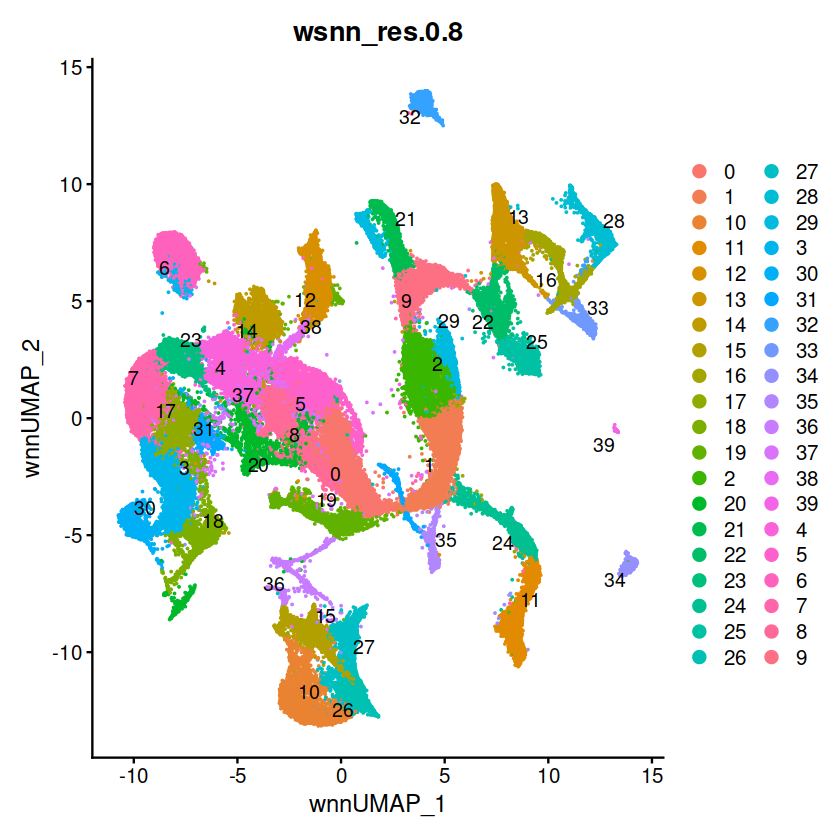

In [7]:
DimPlot(seurat_obj, reduction = "wnn.umap", group.by="wsnn_res.0.8", label=TRUE, repel=TRUE)

In [13]:
seurat_obj$`wsnn_res.0.8` %>% head()

AAACAGCCACCTAAGC-1_1 AAACAGCCAGGGAGGA-1_1 AAACAGCCATAGACCC-1_1 
                  10                   16                   14 
AAACATGCAAACTCAT-1_1 AAACATGCAAGGACCA-1_1 AAACATGCAAGGATTA-1_1 
                   0                    3                    4 
40 Levels: 0 1 10 11 12 13 14 15 16 17 18 19 2 20 21 22 23 24 25 26 27 ... 9

In [ ]:
# recompute the leiden clustering with different resolutions for comparison (coarse and fine)
seurat_obj <- FindClusters(seurat_obj, graph.name = "wsnn", algorithm = 4, 
                           resolution=1, verbose = FALSE)
# save it to the meta.data
seurat_obj$`wsnn_res.1` <- Idents(seurat_obj)

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 67.5 GiB”


In [3]:
# # recompute the leiden clustering with different resolutions for comparison (coarse and fine)
# seurat_obj <- FindClusters(seurat_obj, graph.name = "wsnn", algorithm = 4, 
#                            resolution=1, cluster.name="wsnn_res.1", verbose = FALSE)
# # save it to the meta.data
# seurat_obj$`wsnn_res.1` <- Idents(seurat_obj)

# # resolution=0.5
# seurat_obj <- FindClusters(seurat_obj, graph.name = "wsnn", algorithm = 4, 
#                            resolution=0.5, cluster.name="wsnn_res.0.5", verbose = FALSE)
# # save it to the meta.data
# seurat_obj$`wsnn_res.0.5` <- Idents(seurat_obj)

# # resolution=1.2
# seurat_obj <- FindClusters(seurat_obj, graph.name = "wsnn", algorithm = 4, 
#                            resolution=1.2, cluster.name="wsnn_res.1.2", verbose = FALSE)
# # save it to the meta.data
# seurat_obj$`wsnn_res.1.2` <- Idents(seurat_obj)

In [10]:
seurat_obj@assays[["peaks_integrated"]]@annotation@seqinfo@seqnames

[1] "1"  "2"  "3"  "4"  "5"  "6"  "7"  "8"  "9"  "10" "11" "12" "13" "14" "15"
[16] "16" "17" "18" "19" "20" "21" "22" "23" "24" "25" "MT"

In [38]:
seurat_obj[["peaks_integrated"]]

ChromatinAssay data with 640834 features for 95196 cells
Variable features: 0 
Genome: 
Annotation present: TRUE 
Motifs present: FALSE 
Fragment files: 49 

In [39]:
# step 1. add the genome annotation
# path to the GTF file
gff_path = "/hpc/reference/sequencing_alignment/alignment_references/"
gref_path = paste0(gff_path, "zebrafish_genome_GRCz11/genes/genes.gtf.gz")
gtf_zf <- rtracklayer::import(gref_path)

# make a gene.coord object
gene.coords.zf <- gtf_zf
# filter out the entries without the gene_name
gene.coords.zf <- gene.coords.zf[! is.na(gene.coords.zf$gene_name),]

# only keep the regions within standard chromosomes
gene.coords.zf <- keepStandardChromosomes(gene.coords.zf, pruning.mode = 'coarse')
# name the genome - GRCz11
genome(gene.coords.zf) <- 'GRCz11'

# copy the "gene_id" for the "tx_id" and "transcript_id" 
gene.coords.zf$tx_id <- gene.coords.zf$gene_id
gene.coords.zf$transcript_id <- gene.coords.zf$gene_id

In [40]:
# Extract seqinfo from the annotation
seqinfo_data <- seqinfo(gene.coords.zf)
seqinfo_data

Seqinfo object with 26 sequences from GRCz11 genome; no seqlengths:
  seqnames seqlengths isCircular genome
  1              <NA>       <NA> GRCz11
  2              <NA>       <NA> GRCz11
  3              <NA>       <NA> GRCz11
  4              <NA>       <NA> GRCz11
  5              <NA>       <NA> GRCz11
  ...             ...        ...    ...
  22             <NA>       <NA> GRCz11
  23             <NA>       <NA> GRCz11
  24             <NA>       <NA> GRCz11
  25             <NA>       <NA> GRCz11
  MT             <NA>       <NA> GRCz11

### test for the cds object creation

In [10]:
assay <- "peaks_integrated"
DefaultAssay(seurat_obj) <- assay
print(paste0("default assay is ", assay))

[1] "default assay is peaks_integrated"


In [15]:
seurat_object.cds <- as.cell_data_set(x=seurat_obj)

Warning message in .check_reddim_names(x, value, withDimnames):
“non-NULL 'rownames(value)' should be the same as 'colnames(x)' for
'reducedDim<-'. This will be an error in the next release of
Bioconductor.”
Warning message in .check_reddim_names(x, value[[v]], withDimnames = TRUE, vname = sprintf("value[[%s]]", :
“non-NULL 'rownames(value[[5]])' should be the same as 'colnames(x)' for
'reducedDims<-'. This will be an error in the next release of
Bioconductor.”


In [17]:
seurat_object.cds

class: cell_data_set 
dim: 640834 95196 
metadata(0):
assays(2): counts logcounts
rownames(640834): 1-32-526 1-2372-3057 ... MT-22-3567 MT-13233-16532
rowData names(0):
colnames(95196): AAACAGCCACCTAAGC-1_1 AAACAGCCAGGGAGGA-1_1 ...
  TTTGTTGGTGCGCGTA-1_7 TTTGTTGGTTAAGGCC-1_7
colData names(47): orig.ident nCount_RNA ... ident Size_Factor
reducedDimNames(5): INTEGRATED_LSI UMAP UMAP.RNA UMAP.ATAC WNN.UMAP
mainExpName: peaks_integrated
altExpNames(0):

In [ ]:
# print out the available reduced dimensions
print("Available reduced dimensions:")
print(names(reducedDims(seurat_object.cds)))
# Get the reduced coordinates
reduced_coords <- reducedDims(seurat_object.cds)[[dim_reduced]]
print("name of the dim.reduction")
print(dim_reduced)
print("Class of reduced coordinates:")
print(class(reduced_coords))
print("Dimensions of reduced coordinates:")
print(dim(reduced_coords))

### validate the seurat object (whether it contains the relevant fields or not)


In [32]:
seurat_obj@assays$peaks_integrated

ChromatinAssay data with 640834 features for 95196 cells
Variable features: 0 
Genome: 
Annotation present: TRUE 
Motifs present: FALSE 
Fragment files: 49 

In [23]:
seqinfo

new("standardGeneric", .Data = function (x) 
standardGeneric("seqinfo"), generic = "seqinfo", package = "GenomeInfoDb", 
    group = list(), valueClass = character(0), signature = "x", 
    default = NULL, skeleton = (function (x) 
    stop(gettextf("invalid call in method dispatch to '%s' (no default method)", 
        "seqinfo"), domain = NA))(x))
<bytecode: 0x9fc72c0>
<environment: 0x9fc39c0>
attr(,"generic")
[1] "seqinfo"
attr(,"generic")attr(,"package")
[1] "GenomeInfoDb"
attr(,"package")
[1] "GenomeInfoDb"
attr(,"group")
list()
attr(,"valueClass")
character(0)
attr(,"signature")
[1] "x"
attr(,"default")
`\001NULL\001`
attr(,"skeleton")
(function (x) 
stop(gettextf("invalid call in method dispatch to '%s' (no default method)", 
    "seqinfo"), domain = NA))(x)
attr(,"class")
[1] "standardGeneric"
attr(,"class")attr(,"package")
[1] "methods"

In [21]:
df_seqinfo <- as.data.frame(seurat_obj@assays[[assay]]@seqinfo)
df_seqinfo

<0 x 0 matrix>

In [36]:
seurat@assays[["peaks_integrated"]]@seqinfo

NULL

In [2]:
# data path
data_path = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/"

# TDR118 (15-somites)
TDR118 <- readRDS(paste0(data_path, "TDR118reseq/TDR118_processed.RDS"))


In [3]:
TDR118@reductions

An object of class Seurat 
1573599 features across 13614 samples within 7 assays 
Active assay: peaks_merged (485357 features, 485357 variable features)
 6 other assays present: RNA, ATAC, SCT, peaks_bulk, peaks_celltype, Gene.Activity
 5 dimensional reductions calculated: pca, umap.rna, lsi, umap.atac, umap.joint

In [ ]:
# Set up paths
data_path <- "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/"  # Replace with your actual path
# output_path <- "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/"   # Replace with where you want to save CSVs

# Create list of dataset IDs
dataset_ids <- c("TDR118", "TDR119", "TDR124", "TDR125", "TDR126", "TDR127", "TDR128")

# Function to handle the path based on whether it's a reseq dataset
get_dir_path <- function(id) {
  if (id %in% c("TDR126", "TDR127", "TDR128")) {
    return(paste0(data_path, id))
  } else {
    return(paste0(data_path, id, "reseq"))
  }
}

# Loop through datasets
for (id in dataset_ids) {
  # Construct path
  dir_path <- get_dir_path(id)
  seurat_path <- file.path(dir_path, paste0(id, "_processed.RDS"))
  
  # Load Seurat object
  print(paste("Processing", id))
  seurat_obj <- readRDS(seurat_path)
  
  # Export PCA
  if ("pca" %in% names(seurat_obj@reductions)) {
    pca_df <- as.data.frame(seurat_obj@reductions$pca@cell.embeddings)
    write.csv(pca_df, 
              file = file.path(dir_path, paste0(id, "_pca.csv")))
  }
  
  # Export LSI
  if ("lsi" %in% names(seurat_obj@reductions)) {
    lsi_df <- as.data.frame(seurat_obj@reductions$lsi@cell.embeddings)
    write.csv(lsi_df, 
              file = file.path(dir_path, paste0(id, "_lsi.csv")))
  }
  
  # Clean up to free memory
  rm(seurat_obj)
  gc()
  
  print(paste("Completed processing", id))
}

print("All datasets processed!")

## Check the integrated Seurat object (counts)

In [2]:
# data path
data_path = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_RNA_ATAC_wnn_gene_activity_3d_umaps.rds"

# TDR118 (15-somites)
# TDR118 <- readRDS(paste0(data_path, "TDR118reseq/TDR118_processed.RDS"))
integrated_seurat <- readRDS(data_path)
integrated_seurat

An object of class Seurat 
726063 features across 95196 samples within 5 assays 
Active assay: peaks_integrated (640834 features, 0 variable features)
 4 other assays present: RNA, SCT, integrated, Gene.Activity
 9 dimensional reductions calculated: integrated_lsi, umap, integrated_pca, umap.rna, umap.atac, wnn.umap, umap.rna.3D, umap.atac.3D, wnn.umap.3D

In [4]:
integrated_seurat@assays$peaks_integrated@counts

  [[ suppressing 31 column names ‘AAACAGCCACCTAAGC-1_1’, ‘AAACAGCCAGGGAGGA-1_1’, ‘AAACAGCCATAGACCC-1_1’ ... ]]

  [[ suppressing 31 column names ‘AAACAGCCACCTAAGC-1_1’, ‘AAACAGCCAGGGAGGA-1_1’, ‘AAACAGCCATAGACCC-1_1’ ... ]]

  [[ suppressing 31 column names ‘AAACAGCCACCTAAGC-1_1’, ‘AAACAGCCAGGGAGGA-1_1’, ‘AAACAGCCATAGACCC-1_1’ ... ]]



640834 x 95196 sparse Matrix of class "dgCMatrix"
                                                                                      
1-32-526          . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . ......
1-2372-3057       . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . ......
1-3427-4032       . . 1 . . . . . . . . . . . . . . . . 2 . . . . . . . . . . . ......
1-4469-7268       . . . 1 . . . . 1 . . . 2 . . . . . . . . . . . . . 1 . . . 2 ......
1-9541-9969       . . 1 . . . . . . . . . . . . . . . 1 1 . . . . . . 1 . . . . ......
1-11007-12962     3 . . . . . . . . 1 . 2 . . . . . 2 . 1 . 1 3 . 2 . . 1 . 1 2 ......
1-13276-13705     . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . ......
1-14059-14260     . . . . . . . . . . . . . . . . . . . . . . . . . . . 1 . . . ......
1-14625-15105     . . . 1 . . 1 . . . . 1 . . . . . . 1 . . 1 2 . . . . . . 1 1 ......
1-15724-15934     . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 1 